# Building a Modern Decoder-Only LLM

**RoPE · Grouped-Query Attention · SwiGLU · Pre-RMSNorm - implemented, trained, and benchmarked from scratch**


## 1. Setup




In [1]:
!pip install -q datasets tokenizers

import os, math, time, json, dataclasses
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(1337)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM: %.1f GB" % (torch.cuda.get_device_properties(0).total_memory / 1e9))
else:
    print("WARNING: no GPU detected. Go to Runtime -> Change runtime type -> T4 GPU for a usable training speed.")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
# Optional: mount Google Drive for checkpointing across Colab sessions (sessions can disconnect).
# Uncomment to use. If you skip this, checkpoints are saved locally and lost when the runtime recycles.

# from google.colab import drive
# drive.mount('/content/drive')
# CKPT_ROOT = '/content/drive/MyDrive/transformer_project/checkpoints'
CKPT_ROOT = '/content/checkpoints'
os.makedirs(CKPT_ROOT, exist_ok=True)
print("Checkpoints will be saved under:", CKPT_ROOT)

Checkpoints will be saved under: /content/checkpoints


## 2. The Pipeline, in One Picture


```
text  --tokenize-->  integers  --embed-->  vectors (seq_len, d_model)
      --[N decoder blocks, same shape in and out]-->  vectors (seq_len, d_model)
      --output head-->  scores over every vocabulary word (seq_len, vocab_size)
```



## 3. Hyperparameters and Compute Budget



In [3]:
# ---- architecture size (shared across all 5 ablation variants) ----
D_MODEL      = 384
N_LAYERS     = 6
N_HEADS      = 8          # query heads
N_KV_HEADS_GQA = 2        # KV heads used by the GQA variants (group size = 8/2 = 4)
D_FF_SWIGLU  = 1024        # (8/3) * D_MODEL, parameter-matched to a 4x ReLU FFN
D_FF_RELU    = 4 * D_MODEL
MAX_SEQ_LEN  = 512
VOCAB_SIZE   = 8192

# ---- data / training ----
BLOCK_SIZE       = 256      # training context length (we test extrapolation to 384/512 later)
BATCH_SIZE       = 32
GRAD_ACCUM_STEPS = 2        # effective batch size = BATCH_SIZE * GRAD_ACCUM_STEPS = 64
MAX_LR           = 5e-4
WEIGHT_DECAY     = 0.1
WARMUP_STEPS     = 200
TOTAL_STEPS      = 3000     # ~15-25 min/variant on a T4; lower this for a quick dry run first
EVAL_EVERY       = 300
LOG_EVERY        = 50
CKPT_EVERY       = 1000
GRAD_CLIP        = 1.0

print(f"Approx. tokens seen per full run: {TOTAL_STEPS * BATCH_SIZE * GRAD_ACCUM_STEPS * BLOCK_SIZE:,}")

Approx. tokens seen per full run: 49,152,000


## 4. The Model, Piece by Piece



### 4.1 - Config



In [4]:
@dataclass
class GPTConfig:
    vocab_size: int = 8192
    d_model: int = 384
    n_layers: int = 6
    n_heads: int = 8          # number of QUERY heads
    n_kv_heads: int = 8       # number of KEY/VALUE heads; n_kv_heads == n_heads -> plain MHA
    d_ff: int = 1024
    max_seq_len: int = 512
    dropout: float = 0.0
    use_rope: bool = True     # False -> additive sinusoidal PE instead
    rope_base: float = 10000.0
    norm_type: str = "rmsnorm"   # "rmsnorm" or "layernorm"
    pre_norm: bool = True        # False -> Post-Norm (residual normalized after the add)
    ffn_type: str = "swiglu"     # "swiglu" or "relu"
    tie_weights: bool = True
    bias: bool = False           # linear/norm biases off by default (LLaMA-style)

    def __post_init__(self):
        assert self.d_model % self.n_heads == 0, "d_model must be divisible by n_heads"
        assert self.n_heads % self.n_kv_heads == 0, "n_heads must be divisible by n_kv_heads (GQA groups)"
        self.d_head = self.d_model // self.n_heads

### 4.2 - Normalization: RMSNorm vs. LayerNorm

```
RMS(x)      = sqrt( mean(x_i^2) + eps )
RMSNorm(x)  = (x / RMS(x)) * gamma
```

In [5]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        dtype = x.dtype
        x = x.float()
        rms = torch.rsqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return (x * rms).to(dtype) * self.weight


def build_norm(config: GPTConfig):
    if config.norm_type == "rmsnorm":
        return RMSNorm(config.d_model)
    elif config.norm_type == "layernorm":
        return nn.LayerNorm(config.d_model, bias=config.bias)
    raise ValueError(config.norm_type)

### 4.3 - Positional Encoding: Sinusoidal vs. RoPE


In [6]:
class SinusoidalPositionalEncoding(nn.Module):
    """Original 2017-style additive positional encoding, added once at the input."""
    def __init__(self, d_model, max_seq_len):
        super().__init__()
        pe = torch.zeros(max_seq_len, d_model)
        position = torch.arange(0, max_seq_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe, persistent=False)

    def forward(self, x, start_pos=0):
        seq_len = x.size(1)
        return x + self.pe[start_pos:start_pos + seq_len].unsqueeze(0)


def precompute_rope_cache(d_head, max_seq_len, base=10000.0, device=None, dtype=torch.float32):
    """theta_i = base^(-2i/d_head); returns cos, sin tables of shape (max_seq_len, d_head/2)."""
    inv_freq = 1.0 / (base ** (torch.arange(0, d_head, 2, device=device).float() / d_head))
    t = torch.arange(max_seq_len, device=device).float()
    freqs = torch.outer(t, inv_freq)  # (max_seq_len, d_head/2)
    return freqs.cos().to(dtype), freqs.sin().to(dtype)


def apply_rope(x, cos, sin):
    """
    x:   (batch, n_heads, seq_len, d_head)
    cos, sin: (seq_len, d_head/2), already sliced to the current position range.
    Rotates each adjacent (2i, 2i+1) pair by angle pos * theta_i.
    """
    x1 = x[..., 0::2]   # even indices  (..., d_head/2)
    x2 = x[..., 1::2]   # odd indices
    cos = cos[None, None, :, :]
    sin = sin[None, None, :, :]
    rot_x1 = x1 * cos - x2 * sin
    rot_x2 = x1 * sin + x2 * cos
    out = torch.stack([rot_x1, rot_x2], dim=-1).flatten(-2)  # interleave back
    return out.to(x.dtype)

In [7]:
torch.manual_seed(0)
d_head_test = 8
cos_t, sin_t = precompute_rope_cache(d_head_test, max_seq_len=200)

q = torch.randn(1, 1, 1, d_head_test)
k = torch.randn(1, 1, 1, d_head_test)

def rotated_dot(m, n):
    qm = apply_rope(q, cos_t[m:m+1], sin_t[m:m+1])
    kn = apply_rope(k, cos_t[n:n+1], sin_t[n:n+1])
    return (qm * kn).sum().item()

for m, n in [(5, 2), (105, 102), (50, 47), (3, 0)]:
    print(f"m={m:4d}, n={n:4d}, m-n={m-n}:  dot product = {rotated_dot(m, n):.6f}")

print("\nAll four rows share m-n=3 and should show the identical dot product -> RoPE encodes RELATIVE position only.")

m=   5, n=   2, m-n=3:  dot product = 1.178293
m= 105, n= 102, m-n=3:  dot product = 1.178293
m=  50, n=  47, m-n=3:  dot product = 1.178293
m=   3, n=   0, m-n=3:  dot product = 1.178293

All four rows share m-n=3 and should show the identical dot product -> RoPE encodes RELATIVE position only.


### 4.4 - Attention: Multi-Head and Grouped-Query, Unified



In [8]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.n_heads = config.n_heads
        self.n_kv_heads = config.n_kv_heads
        self.n_rep = config.n_heads // config.n_kv_heads   # group size G
        self.d_head = config.d_head
        self.use_rope = config.use_rope

        self.wq = nn.Linear(config.d_model, config.n_heads * self.d_head, bias=config.bias)
        self.wk = nn.Linear(config.d_model, config.n_kv_heads * self.d_head, bias=config.bias)
        self.wv = nn.Linear(config.d_model, config.n_kv_heads * self.d_head, bias=config.bias)
        self.wo = nn.Linear(config.n_heads * self.d_head, config.d_model, bias=config.bias)
        self.dropout = config.dropout

    def forward(self, x, cos=None, sin=None, past_kv=None, use_cache=False):
        B, T, _ = x.shape
        q = self.wq(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)      # (B, HQ, T, dh)
        k = self.wk(x).view(B, T, self.n_kv_heads, self.d_head).transpose(1, 2)   # (B, HKV, T, dh)
        v = self.wv(x).view(B, T, self.n_kv_heads, self.d_head).transpose(1, 2)

        if self.use_rope:
            q = apply_rope(q, cos, sin)
            k = apply_rope(k, cos, sin)

        if past_kv is not None:
            past_k, past_v = past_kv
            k = torch.cat([past_k, k], dim=2)
            v = torch.cat([past_v, v], dim=2)
        present_kv = (k, v) if use_cache else None

        # --- expand shared KV heads across each group of query heads (the GQA "broadcast") ---
        if self.n_rep > 1:
            k_e = k.repeat_interleave(self.n_rep, dim=1)   # (B, HQ, S_kv, dh)
            v_e = v.repeat_interleave(self.n_rep, dim=1)
        else:
            k_e, v_e = k, v

        T_kv = k_e.size(2)
        scores = (q @ k_e.transpose(-2, -1)) / math.sqrt(self.d_head)   # (B, HQ, T, T_kv)

        if past_kv is None:
            # standard training-time causal mask (T == T_kv)
            causal = torch.triu(torch.ones(T, T_kv, device=x.device, dtype=torch.bool), diagonal=1)
            scores = scores.masked_fill(causal, float("-inf"))
        # else: decoding a single new token attending to the full cache -> no mask needed
        # (every cached position is, by construction, at or before the current one)

        attn = F.softmax(scores, dim=-1)
        attn = F.dropout(attn, p=self.dropout, training=self.training)
        out = attn @ v_e                                    # (B, HQ, T, dh)
        out = out.transpose(1, 2).contiguous().view(B, T, self.n_heads * self.d_head)
        out = self.wo(out)
        return out, present_kv

### 4.5 - Feed-Forward: ReLU vs. SwiGLU



In [9]:
class ReLUFeedForward(nn.Module):
    """Original: FFN(x) = ReLU(x W1 + b1) W2 + b2, hidden = 4 * d_model."""
    def __init__(self, config: GPTConfig):
        super().__init__()
        hidden = 4 * config.d_model
        self.w1 = nn.Linear(config.d_model, hidden, bias=config.bias)
        self.w2 = nn.Linear(hidden, config.d_model, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.dropout(self.w2(F.relu(self.w1(x))))


class SwiGLUFeedForward(nn.Module):
    """SwiGLU(x) = (Swish(x Wgate) * (x Wup)) Wdown ; hidden ~ (8/3) * d_model for param parity."""
    def __init__(self, config: GPTConfig):
        super().__init__()
        hidden = config.d_ff
        self.w_gate = nn.Linear(config.d_model, hidden, bias=config.bias)
        self.w_up = nn.Linear(config.d_model, hidden, bias=config.bias)
        self.w_down = nn.Linear(hidden, config.d_model, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        gate = F.silu(self.w_gate(x))   # silu == swish with beta=1
        return self.dropout(self.w_down(gate * self.w_up(x)))


def build_ffn(config: GPTConfig):
    return SwiGLUFeedForward(config) if config.ffn_type == "swiglu" else ReLUFeedForward(config)

### 4.6 - Assembling One Block: Pre-Norm vs. Post-Norm



In [10]:
class Block(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.pre_norm = config.pre_norm
        self.norm1 = build_norm(config)
        self.attn = CausalSelfAttention(config)
        self.norm2 = build_norm(config)
        self.ffn = build_ffn(config)

    def forward(self, x, cos=None, sin=None, past_kv=None, use_cache=False):
        if self.pre_norm:
            attn_out, present_kv = self.attn(self.norm1(x), cos, sin, past_kv, use_cache)
            x = x + attn_out
            x = x + self.ffn(self.norm2(x))
        else:
            attn_out, present_kv = self.attn(x, cos, sin, past_kv, use_cache)
            x = self.norm1(x + attn_out)
            x = self.norm2(x + self.ffn(x))
        return x, present_kv

### 4.7 - The Full Model



In [11]:
class GPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.d_model)
        self.dropout = nn.Dropout(config.dropout)

        if not config.use_rope:
            self.pos_enc = SinusoidalPositionalEncoding(config.d_model, config.max_seq_len)
            cos, sin = None, None
        else:
            self.pos_enc = None
            cos, sin = precompute_rope_cache(config.d_head, config.max_seq_len, config.rope_base)
        self.register_buffer("rope_cos", cos, persistent=False)
        self.register_buffer("rope_sin", sin, persistent=False)

        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layers)])
        self.norm_f = build_norm(config)
        self.lm_head = nn.Linear(config.d_model, config.vocab_size, bias=False)

        if config.tie_weights:
            self.lm_head.weight = self.tok_emb.weight   # weight tying

        self.apply(self._init_weights)
        for name, p in self.named_parameters():
            if name.endswith("wo.weight") or name.endswith("w_down.weight") or name.endswith("w2.weight"):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layers))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok_emb(idx)
        x = self.dropout(x)
        if self.pos_enc is not None:
            x = self.pos_enc(x)
            cos, sin = None, None
        else:
            cos, sin = self.rope_cos[:T], self.rope_sin[:T]

        for block in self.blocks:
            x, _ = block(x, cos, sin, past_kv=None, use_cache=False)
        x = self.norm_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_p=0.9, use_cache=True):
        """Autoregressive generation with KV caching: one parallel 'prefill' pass over the
        prompt, then one token at a time during 'decode', reusing cached K/V (manual Section 12)."""
        self.eval()
        B, T0 = idx.shape
        past_kvs = [None] * len(self.blocks) if use_cache else None

        x = self.tok_emb(idx)
        if self.pos_enc is not None:
            x = self.pos_enc(x)
            cos, sin = None, None
        else:
            cos, sin = self.rope_cos[:T0], self.rope_sin[:T0]
        for i, block in enumerate(self.blocks):
            x, kv = block(x, cos, sin, past_kv=None, use_cache=use_cache)
            if use_cache:
                past_kvs[i] = kv
        x = self.norm_f(x)
        logits = self.lm_head(x[:, -1:, :])

        generated = idx
        cur_pos = T0
        for _ in range(max_new_tokens):
            probs = self._logits_to_probs(logits[:, -1, :], temperature, top_p)
            next_tok = torch.multinomial(probs, num_samples=1)
            generated = torch.cat([generated, next_tok], dim=1)

            x = self.tok_emb(next_tok)
            if self.pos_enc is not None:
                x = self.pos_enc(x, start_pos=cur_pos)
                cos, sin = None, None
            else:
                cos, sin = self.rope_cos[cur_pos:cur_pos + 1], self.rope_sin[cur_pos:cur_pos + 1]
            for i, block in enumerate(self.blocks):
                past = past_kvs[i] if use_cache else None
                x, kv = block(x, cos, sin, past_kv=past, use_cache=use_cache)
                if use_cache:
                    past_kvs[i] = kv
            x = self.norm_f(x)
            logits = self.lm_head(x)
            cur_pos += 1
        return generated

    @staticmethod
    def _logits_to_probs(logits, temperature, top_p):
        logits = logits / max(temperature, 1e-5)
        probs = F.softmax(logits, dim=-1)
        if top_p is not None and top_p < 1.0:
            sorted_probs, sorted_idx = torch.sort(probs, descending=True, dim=-1)
            cum_probs = torch.cumsum(sorted_probs, dim=-1)
            cutoff = (cum_probs > top_p).float().argmax(dim=-1, keepdim=True)
            cutoff = torch.clamp(cutoff, min=0)
            mask = torch.arange(sorted_probs.size(-1), device=logits.device)[None, :] <= cutoff
            sorted_probs = sorted_probs * mask
            sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
            probs = torch.zeros_like(probs).scatter(-1, sorted_idx, sorted_probs)
        return probs

In [12]:
def _greedy_no_cache(model, idx, steps):
    idx = idx.clone()
    for _ in range(steps):
        logits, _ = model(idx)
        nxt = logits[:, -1, :].argmax(-1, keepdim=True)
        idx = torch.cat([idx, nxt], dim=1)
    return idx

_test_cfg = GPTConfig(vocab_size=200, d_model=64, n_layers=2, n_heads=4, n_kv_heads=2,
                       d_ff=128, max_seq_len=64, use_rope=True, tie_weights=True)
_test_model = GPT(_test_cfg).eval()
_prompt = torch.randint(0, 200, (1, 5))

torch.manual_seed(42)
no_cache = _greedy_no_cache(_test_model, _prompt, 10)
torch.manual_seed(42)
with_cache = _test_model.generate(_prompt, max_new_tokens=10, temperature=1e-8, top_p=1.0, use_cache=True)

print("no cache:  ", no_cache.tolist())
print("with cache:", with_cache.tolist())
assert torch.equal(no_cache, with_cache), "KV-cache generation must match uncached generation exactly!"
print("\nKV-CACHE CORRECTNESS CHECK: PASSED")

no cache:   [[177, 157, 48, 106, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44]]
with cache: [[177, 157, 48, 106, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44]]

KV-CACHE CORRECTNESS CHECK: PASSED


## 5. Parameter Accounting



In [13]:
def param_breakdown(model):
    cfg = model.config
    rows = []
    emb = model.tok_emb.weight.numel()
    rows.append(("Token embedding", emb))

    blk = model.blocks[0]
    norm_params = sum(p.numel() for p in blk.norm1.parameters()) + \
                  sum(p.numel() for p in blk.norm2.parameters())
    wq = sum(p.numel() for p in blk.attn.wq.parameters())
    wk = sum(p.numel() for p in blk.attn.wk.parameters())
    wv = sum(p.numel() for p in blk.attn.wv.parameters())
    wo = sum(p.numel() for p in blk.attn.wo.parameters())
    ffn_params = sum(p.numel() for p in blk.ffn.parameters())

    per_block = norm_params + wq + wk + wv + wo + ffn_params
    rows += [
        ("Per-block: norms", norm_params),
        ("Per-block: Wq", wq),
        ("Per-block: Wk+Wv", wk + wv),
        ("Per-block: Wo", wo),
        (f"Per-block: FFN ({cfg.ffn_type})", ffn_params),
        ("Per-block subtotal", per_block),
        (f"All {cfg.n_layers} blocks", per_block * cfg.n_layers),
    ]
    final_norm = sum(p.numel() for p in model.norm_f.parameters())
    rows.append(("Final norm", final_norm))
    head = 0 if cfg.tie_weights else model.lm_head.weight.numel()
    rows.append(("Output head (0 if tied)", head))
    total = emb + per_block * cfg.n_layers + final_norm + head
    rows.append(("TOTAL", total))
    return rows


def print_breakdown(model):
    rows = param_breakdown(model)
    width = max(len(r[0]) for r in rows)
    for name, count in rows:
        print(f"  {name.ljust(width)} : {count:,}")


# sanity-check on the reference "final" (fully modernized) config
_ref_cfg = GPTConfig(vocab_size=VOCAB_SIZE, d_model=D_MODEL, n_layers=N_LAYERS,
                      n_heads=N_HEADS, n_kv_heads=N_KV_HEADS_GQA, d_ff=D_FF_SWIGLU,
                      max_seq_len=MAX_SEQ_LEN, use_rope=True, norm_type="rmsnorm",
                      pre_norm=True, ffn_type="swiglu", tie_weights=True)
_ref_model = GPT(_ref_cfg)
print_breakdown(_ref_model)
del _ref_model

  Token embedding         : 3,145,728
  Per-block: norms        : 768
  Per-block: Wq           : 147,456
  Per-block: Wk+Wv        : 73,728
  Per-block: Wo           : 147,456
  Per-block: FFN (swiglu) : 1,179,648
  Per-block subtotal      : 1,549,056
  All 6 blocks            : 9,294,336
  Final norm              : 384
  Output head (0 if tied) : 0
  TOTAL                   : 12,440,448


## 6. Tokenizer and Data Pipeline

### 6.1 - Byte-Pair Encoding, trained from scratch



In [14]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders
from datasets import load_dataset

print("Downloading TinyStories (this can take a minute the first time)...")
raw_train = load_dataset("roneneldan/TinyStories", split="train")
raw_val   = load_dataset("roneneldan/TinyStories", split="validation")
print(f"train examples: {len(raw_train):,}   val examples: {len(raw_val):,}")
print("\nExample story:\n", raw_train[0]["text"])

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            

data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

data/train-00001-of-00004-5852b56a2bd28f(…): reconstructing file:   0%|          |  0.00B /  248MB            

data/train-00001-of-00004-5852b56a2bd28f(…): downloading bytes:           |  0.00B            

...

data/validation-00000-of-00001-869c898b5(…): reconstructing file:   0%|          |  0.00B / 9.99MB            

data/validation-00000-of-00001-869c898b5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

train examples: 2,119,719   val examples: 21,990

Example story:
 One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.


In [15]:
TOKENIZER_PATH = "/content/tinystories_bpe.json"

def train_tokenizer(dataset, vocab_size, save_path):
    tok = Tokenizer(models.BPE(unk_token="<unk>"))
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["<pad>", "<bos>", "<eos>", "<unk>"],
        min_frequency=2,
        show_progress=True,
    )
    def text_iterator():
        for row in dataset:
            yield row["text"]
    tok.train_from_iterator(text_iterator(), trainer=trainer)
    tok.save(save_path)
    return tok

tokenizer = train_tokenizer(raw_train, VOCAB_SIZE, TOKENIZER_PATH)
EOS_ID = tokenizer.token_to_id("<eos>")

# round-trip sanity check
sample = raw_train[0]["text"][:80]
ids = tokenizer.encode(sample).ids
print("original: ", sample)
print("token ids:", ids[:20], "...")
print("decoded:  ", tokenizer.decode(ids))
print("\nvocab size actually used:", tokenizer.get_vocab_size())

original:  One day, a little girl named Lily found a needle in her room. She knew it was di
token ids: [318, 254, 15, 157, 295, 344, 398, 262, 493, 157, 3630, 214, 207, 656, 17, 211, 601, 202, 180, 2192] ...
decoded:   One day, a little girl named Lily found a needle in her room. She knew it was di

vocab size actually used: 8192


### 6.2 - Chunking: the Teacher-Forcing Input/Target Construction



In [16]:
class ChunkedTokenDataset(Dataset):
    def __init__(self, token_ids, block_size):
        self.block_size = block_size
        n_chunks = (len(token_ids) - 1) // block_size
        usable = n_chunks * block_size + 1
        self.data = torch.tensor(token_ids[:usable], dtype=torch.long)
        self.n_chunks = n_chunks

    def __len__(self):
        return self.n_chunks

    def __getitem__(self, idx):
        start = idx * self.block_size
        x = self.data[start: start + self.block_size]
        y = self.data[start + 1: start + self.block_size + 1]
        return x, y


def tokenize_and_concat(dataset, tokenizer, max_examples=None):
    ids = []
    n = len(dataset) if max_examples is None else min(max_examples, len(dataset))
    for i in range(n):
        ids.extend(tokenizer.encode(dataset[i]["text"]).ids)
        ids.append(EOS_ID)
    return ids

# NOTE: tokenizing the *full* 2.1M-example TinyStories train split takes a while.
# MAX_TRAIN_EXAMPLES caps it for a reasonable first run; raise it (or set to None) once
# the pipeline is confirmed working end to end.
MAX_TRAIN_EXAMPLES = 200_000
MAX_VAL_EXAMPLES = 5_000

print("Tokenizing train split...")
train_ids = tokenize_and_concat(raw_train, tokenizer, MAX_TRAIN_EXAMPLES)
print("Tokenizing val split...")
val_ids = tokenize_and_concat(raw_val, tokenizer, MAX_VAL_EXAMPLES)
print(f"train tokens: {len(train_ids):,}   val tokens: {len(val_ids):,}")

def make_dataloaders(train_ids, val_ids, block_size, batch_size):
    train_ds = ChunkedTokenDataset(train_ids, block_size)
    val_ds = ChunkedTokenDataset(val_ids, block_size)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                               num_workers=2, drop_last=True, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                             num_workers=2, drop_last=True, pin_memory=True)
    return train_loader, val_loader

train_loader, val_loader = make_dataloaders(train_ids, val_ids, BLOCK_SIZE, BATCH_SIZE)
print(f"train batches/epoch: {len(train_loader):,}   val batches: {len(val_loader):,}")
xb, yb = next(iter(train_loader))
print("batch shapes:", xb.shape, yb.shape)

Tokenizing train split...
Tokenizing val split...
train tokens: 44,280,733   val tokens: 983,332
train batches/epoch: 5,405   val batches: 120
batch shapes: torch.Size([32, 256]) torch.Size([32, 256])


## 7. Training Utilities



In [17]:
def build_optimizer(model, lr, weight_decay, betas=(0.9, 0.95)):
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (decay if p.dim() >= 2 else no_decay).append(p)
    groups = [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]
    return torch.optim.AdamW(groups, lr=lr, betas=betas)


def lr_schedule(step, warmup_steps, total_steps, max_lr, min_lr_ratio=0.1):
    if step < warmup_steps:
        return max_lr * step / max(warmup_steps, 1)
    if step >= total_steps:
        return max_lr * min_lr_ratio
    progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    coeff = 0.5 * (1.0 + math.cos(math.pi * progress))
    return max_lr * min_lr_ratio + coeff * max_lr * (1 - min_lr_ratio)


class Trainer:
    def __init__(self, model, train_loader, val_loader, device, max_lr, weight_decay, use_amp=True):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.max_lr = max_lr
        self.optimizer = build_optimizer(model, lr=max_lr, weight_decay=weight_decay)
        self.use_amp = use_amp and device == "cuda"
        self.scaler = torch.amp.GradScaler("cuda", enabled=self.use_amp)
        self.history = {"step": [], "train_loss": [], "val_step": [], "val_loss": []}

    def _forward_loss(self, x, y):
        with torch.autocast(device_type="cuda" if self.use_amp else "cpu",
                             dtype=torch.float16, enabled=self.use_amp):
            _, loss = self.model(x, y)
        return loss

    @torch.no_grad()
    def evaluate(self, max_batches=20):
        self.model.eval()
        total, n = 0.0, 0
        for i, (x, y) in enumerate(self.val_loader):
            if i >= max_batches:
                break
            x, y = x.to(self.device), y.to(self.device)
            loss = self._forward_loss(x, y)
            total += loss.item(); n += 1
        self.model.train()
        return total / max(n, 1)

    def train(self, total_steps, warmup_steps, grad_accum_steps, grad_clip,
              eval_every, log_every, ckpt_path=None, ckpt_every=1000, tag=""):
        self.model.train()
        train_iter = iter(self.train_loader)
        t0 = time.time()
        for step in range(total_steps):
            lr = lr_schedule(step, warmup_steps, total_steps, self.max_lr)
            for g in self.optimizer.param_groups:
                g["lr"] = lr

            self.optimizer.zero_grad(set_to_none=True)
            accum_loss = 0.0
            for _ in range(grad_accum_steps):
                try:
                    x, y = next(train_iter)
                except StopIteration:
                    train_iter = iter(self.train_loader)
                    x, y = next(train_iter)
                x, y = x.to(self.device, non_blocking=True), y.to(self.device, non_blocking=True)
                loss = self._forward_loss(x, y) / grad_accum_steps
                self.scaler.scale(loss).backward()
                accum_loss += loss.item()

            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), grad_clip)
            self.scaler.step(self.optimizer)
            self.scaler.update()

            if step % log_every == 0:
                print(f"[{tag}] step {step:5d}/{total_steps}  lr={lr:.2e}  "
                      f"loss={accum_loss:.4f}  ({time.time()-t0:.0f}s)")
                self.history["step"].append(step)
                self.history["train_loss"].append(accum_loss)

            if step % eval_every == 0 and step > 0:
                vl = self.evaluate()
                print(f"  [{tag}] -> val_loss={vl:.4f}  val_ppl={math.exp(vl):.2f}")
                self.history["val_step"].append(step)
                self.history["val_loss"].append(vl)

            if ckpt_path is not None and step % ckpt_every == 0 and step > 0:
                torch.save({"model": self.model.state_dict(), "step": step,
                            "config": dataclasses.asdict(self.model.config)}, ckpt_path)

        final_vl = self.evaluate()
        self.history["val_step"].append(total_steps)
        self.history["val_loss"].append(final_vl)
        print(f"[{tag}] FINAL val_loss={final_vl:.4f}  val_ppl={math.exp(final_vl):.2f}")
        return self.history

## 8. The Ablation Ladder


| Variant | Position enc. | Attention | Norm | FFN | Isolates |
|---|---|---|---|---|---|
| `baseline` | Sinusoidal | MHA | Post-LN | ReLU | Faithful 2017 reproduction - control group |
| `rope` | RoPE | MHA | Post-LN | ReLU | Effect of relative positional encoding alone |
| `rope_gqa` | RoPE | GQA | Post-LN | ReLU | Adds inference memory/throughput efficiency |
| `rope_gqa_swiglu` | RoPE | GQA | Post-LN | SwiGLU | Adds gated FFN sample efficiency |
| `final` | RoPE | GQA | Pre-RMSNorm | SwiGLU | Fully modernized architecture |


In [18]:
def make_config(use_rope, n_kv_heads, norm_type, pre_norm, ffn_type):
    d_ff = D_FF_SWIGLU if ffn_type == "swiglu" else D_FF_RELU
    bias = (norm_type == "layernorm")  # baseline-style variants keep biases on, matching the 2017 paper
    return GPTConfig(
        vocab_size=VOCAB_SIZE, d_model=D_MODEL, n_layers=N_LAYERS, n_heads=N_HEADS,
        n_kv_heads=n_kv_heads, d_ff=d_ff, max_seq_len=MAX_SEQ_LEN,
        use_rope=use_rope, norm_type=norm_type, pre_norm=pre_norm, ffn_type=ffn_type,
        tie_weights=True, bias=bias,
    )

ABLATION_CONFIGS = {
    "baseline":         make_config(use_rope=False, n_kv_heads=N_HEADS,        norm_type="layernorm", pre_norm=False, ffn_type="relu"),
    "rope":             make_config(use_rope=True,  n_kv_heads=N_HEADS,        norm_type="layernorm", pre_norm=False, ffn_type="relu"),
    "rope_gqa":         make_config(use_rope=True,  n_kv_heads=N_KV_HEADS_GQA, norm_type="layernorm", pre_norm=False, ffn_type="relu"),
    "rope_gqa_swiglu":  make_config(use_rope=True,  n_kv_heads=N_KV_HEADS_GQA, norm_type="layernorm", pre_norm=False, ffn_type="swiglu"),
    "final":            make_config(use_rope=True,  n_kv_heads=N_KV_HEADS_GQA, norm_type="rmsnorm",   pre_norm=True,  ffn_type="swiglu"),
}

print(f"{'variant':<18s} {'params':>12s}")
for name, cfg in ABLATION_CONFIGS.items():
    n = sum(p.numel() for p in GPT(cfg).parameters())
    print(f"{name:<18s} {n:>12,}")

variant                  params
baseline             13,793,280
rope                 13,793,280
rope_gqa             12,462,720
rope_gqa_swiglu      12,465,792
final                12,440,448


## 9. Training Run



In [19]:
all_histories = {}
all_models = {}

for name, cfg in ABLATION_CONFIGS.items():
    print(f"\n{'='*70}\nTraining variant: {name}\n{'='*70}")
    model = GPT(cfg)
    trainer = Trainer(model, train_loader, val_loader, device,
                       max_lr=MAX_LR, weight_decay=WEIGHT_DECAY, use_amp=True)
    ckpt_path = os.path.join(CKPT_ROOT, f"{name}.pt")
    history = trainer.train(
        total_steps=TOTAL_STEPS, warmup_steps=WARMUP_STEPS,
        grad_accum_steps=GRAD_ACCUM_STEPS, grad_clip=GRAD_CLIP,
        eval_every=EVAL_EVERY, log_every=LOG_EVERY,
        ckpt_path=ckpt_path, ckpt_every=CKPT_EVERY, tag=name,
    )
    torch.save({"model": model.state_dict(), "config": dataclasses.asdict(cfg)}, ckpt_path)
    all_histories[name] = history
    all_models[name] = model.to("cpu")   # move off GPU between runs to free VRAM
    torch.cuda.empty_cache() if device == "cuda" else None

print("\nAll five variants trained and checkpointed.")


Training variant: baseline
[baseline] step     0/3000  lr=0.00e+00  loss=9.0979  (1s)
[baseline] step    50/3000  lr=1.25e-04  loss=7.0552  (11s)
[baseline] step   100/3000  lr=2.50e-04  loss=5.9888  (21s)
[baseline] step   150/3000  lr=3.75e-04  loss=5.9603  (31s)
[baseline] step   200/3000  lr=5.00e-04  loss=5.9778  (41s)
[baseline] step   250/3000  lr=5.00e-04  loss=5.5941  (51s)
[baseline] step   300/3000  lr=4.99e-04  loss=5.2876  (62s)
  [baseline] -> val_loss=5.3280  val_ppl=206.03
[baseline] step   350/3000  lr=4.97e-04  loss=5.0179  (73s)
[baseline] step   400/3000  lr=4.94e-04  loss=4.9084  (83s)
[baseline] step   450/3000  lr=4.91e-04  loss=4.7800  (93s)
[baseline] step   500/3000  lr=4.87e-04  loss=4.8600  (103s)
[baseline] step   550/3000  lr=4.83e-04  loss=4.6337  (114s)
[baseline] step   600/3000  lr=4.78e-04  loss=4.7461  (124s)
  [baseline] -> val_loss=4.6060  val_ppl=100.08
[baseline] step   650/3000  lr=4.72e-04  loss=4.5833  (135s)
[baseline] step   700/3000  lr=4.

## 10. Evaluation Suite


### 10.1 - Final Perplexity Comparison

In [20]:
print(f"{'variant':<18s} {'final val loss':>15s} {'perplexity':>12s}")
for name, hist in all_histories.items():
    vl = hist["val_loss"][-1]
    print(f"{name:<18s} {vl:>15.4f} {math.exp(vl):>12.2f}")

variant             final val loss   perplexity
baseline                    3.1178        22.60
rope                        1.9594         7.10
rope_gqa                    1.9759         7.21
rope_gqa_swiglu             1.9038         6.71
final                       1.7897         5.99


### 10.2 - Overlaid Training Loss Curves

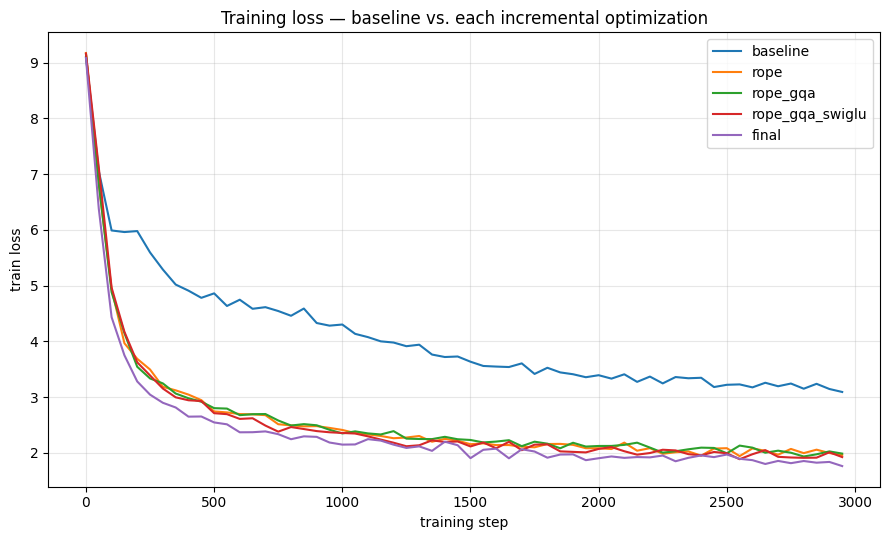

In [21]:
plt.figure(figsize=(9, 5.5))
for name, hist in all_histories.items():
    plt.plot(hist["step"], hist["train_loss"], label=name, linewidth=1.5)
plt.xlabel("training step")
plt.ylabel("train loss")
plt.title("Training loss — baseline vs. each incremental optimization")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/loss_curves.png", dpi=150)
plt.show()

### 10.3 - Length-Extrapolation Test (RoPE vs. Sinusoidal)



baseline {128: '24.0', 256: '24.4', 384: '128.3', 512: '288.0'}
final {128: '7.3', 256: '7.0', 384: '7.4', 512: '10.3'}


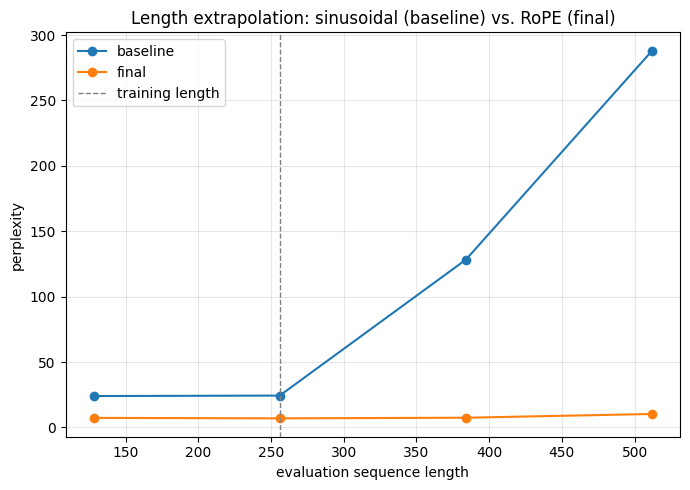

In [22]:
@torch.no_grad()
def eval_at_length(model, token_ids, seq_len, device, n_batches=10, batch_size=8):
    model.eval().to(device)
    losses = []
    max_start = len(token_ids) - seq_len - 1
    for i in range(n_batches):
        xs, ys = [], []
        for b in range(batch_size):
            start = torch.randint(0, max_start, (1,)).item()
            chunk = token_ids[start:start + seq_len + 1]
            xs.append(chunk[:-1]); ys.append(chunk[1:])
        x = torch.tensor(xs, dtype=torch.long, device=device)
        y = torch.tensor(ys, dtype=torch.long, device=device)
        _, loss = model(x, y)
        losses.append(loss.item())
    model.to("cpu")
    return math.exp(sum(losses) / len(losses))

extrap_lengths = [128, 256, 384, 512]  # BLOCK_SIZE=256 is the training length
extrap_results = {}
for name in ["baseline", "final"]:
    extrap_results[name] = [eval_at_length(all_models[name], val_ids, L, device) for L in extrap_lengths]
    print(name, dict(zip(extrap_lengths, [f"{p:.1f}" for p in extrap_results[name]])))

plt.figure(figsize=(7, 5))
for name in ["baseline", "final"]:
    plt.plot(extrap_lengths, extrap_results[name], marker="o", label=name)
plt.axvline(BLOCK_SIZE, color="gray", linestyle="--", linewidth=1, label="training length")
plt.xlabel("evaluation sequence length")
plt.ylabel("perplexity")
plt.title("Length extrapolation: sinusoidal (baseline) vs. RoPE (final)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/length_extrapolation.png", dpi=150)
plt.show()

### 10.4 - KV-Cache Memory and Decode Throughput (GQA vs. Full MHA)



In [23]:
@torch.no_grad()
def measured_kv_cache_bytes(model, batch_size=1, seq_len=256, device="cpu"):
    model.eval().to(device)
    idx = torch.randint(0, model.config.vocab_size, (batch_size, seq_len), device=device)
    x = model.tok_emb(idx)
    if model.pos_enc is not None:
        x = model.pos_enc(x); cos, sin = None, None
    else:
        cos, sin = model.rope_cos[:seq_len], model.rope_sin[:seq_len]
    total_bytes = 0
    for block in model.blocks:
        x, kv = block(x, cos, sin, past_kv=None, use_cache=True)
        k, v = kv
        total_bytes += k.element_size() * k.nelement() + v.element_size() * v.nelement()
    model.to("cpu")
    return total_bytes


@torch.no_grad()
def decode_throughput(model, prompt_len, n_generate, device, use_cache=True):
    model.eval().to(device)
    idx = torch.randint(0, model.config.vocab_size, (1, prompt_len), device=device)
    if device == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    model.generate(idx, max_new_tokens=n_generate, temperature=1.0, top_p=1.0, use_cache=use_cache)
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    model.to("cpu")
    return n_generate / elapsed, elapsed


mha_twin_cfg = make_config(use_rope=True, n_kv_heads=N_HEADS, norm_type="rmsnorm",
                            pre_norm=True, ffn_type="swiglu")
mha_twin = GPT(mha_twin_cfg)   # untrained is fine -- we're only measuring memory/speed, not quality

for seq_len in [256, 512]:
    b_gqa = measured_kv_cache_bytes(all_models["final"], seq_len=seq_len, device=device)
    b_mha = measured_kv_cache_bytes(mha_twin, seq_len=seq_len, device=device)
    print(f"S={seq_len:4d}:  GQA cache = {b_gqa/1024:.1f} KB   MHA cache = {b_mha/1024:.1f} KB   "
          f"reduction = {b_mha/b_gqa:.2f}x")

print()
tps_gqa, _ = decode_throughput(all_models["final"], prompt_len=32, n_generate=128, device=device)
tps_mha, _ = decode_throughput(mha_twin, prompt_len=32, n_generate=128, device=device)
print(f"Decode throughput  GQA: {tps_gqa:.1f} tok/s   MHA: {tps_mha:.1f} tok/s")
print("(Differences are modest at this tiny model/context scale -- see the manual, Section 7.4, for why "
      "the same ratio becomes decisive at 7B+ parameter scale and long contexts / large batch serving.)")

S= 256:  GQA cache = 1152.0 KB   MHA cache = 4608.0 KB   reduction = 4.00x
S= 512:  GQA cache = 2304.0 KB   MHA cache = 9216.0 KB   reduction = 4.00x

Decode throughput  GQA: 110.5 tok/s   MHA: 138.5 tok/s
(Differences are modest at this tiny model/context scale -- see the manual, Section 7.4, for why the same ratio becomes decisive at 7B+ parameter scale and long contexts / large batch serving.)


### 10.5 - Generation Samples, Side by Side




In [24]:
FIXED_PROMPTS = [
    "Once upon a time, there was a little girl named",
    "The dog ran into the forest and",
    "One day, Tom found a strange box. He opened it and",
]

def generate_text(model, tokenizer, prompt, max_new_tokens=60, device=device):
    model.eval().to(device)
    ids = tokenizer.encode(prompt).ids
    x = torch.tensor([ids], dtype=torch.long, device=device)
    out = model.generate(x, max_new_tokens=max_new_tokens, temperature=0.8, top_p=0.9, use_cache=True)
    model.to("cpu")
    return tokenizer.decode(out[0].tolist())

for prompt in FIXED_PROMPTS:
    print(f"\nPROMPT: {prompt!r}\n" + "-" * 70)
    for name, model in all_models.items():
        text = generate_text(model, tokenizer, prompt)
        print(f"[{name}]\n  {text}\n")


PROMPT: 'Once upon a time, there was a little girl named'
----------------------------------------------------------------------
[baseline]
  Once upon a time, there was a little girl named Lily. She loved to play outside with her friends. One day, she saw a big box and the sky. Lily had a very pretty dress. She wanted to eat it, but it was too long, but she saw it. 

"Wow, I like you are so pretty!" Lily

[rope]
  Once upon a time, there was a little girl named Lily. She loved to play with her toys and run around outside. One day, Lily's mom asked her to help her clean up. Lily didn't want to, but she wanted to help. She looked for the dust in the corner and found it. 

Lily found a cloth and wrapped

[rope_gqa]
  Once upon a time, there was a little girl named Lily. She loved to play with her toys and explore her house. One day, Lily went to the park with her mommy and daddy. They saw a big tree and Lily wanted to climb it. She climbed up the tree and started to climb up.

As they w

### 10.6 - Reloading a Saved Checkpoint




In [25]:
ckpt = torch.load(os.path.join(CKPT_ROOT, "final.pt"), weights_only=True, map_location="cpu")
reloaded_config = GPTConfig(**ckpt["config"])
reloaded_model = GPT(reloaded_config)
reloaded_model.load_state_dict(ckpt["model"])
reloaded_model.eval()
print("Reloaded model parameter count:", sum(p.numel() for p in reloaded_model.parameters()))
print(generate_text(reloaded_model, tokenizer, "Once upon a time,", max_new_tokens=40))

Reloaded model parameter count: 12440448
Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she found a big, green bug crawling on the ground. She was so excited and started to jump
